# Customer Churn Prediction Analysis

## Business Problem
Customer churn is a critical business metric that directly impacts revenue and growth.
This analysis aims to:
- Predict which customers are at risk of churning (binary classification)
- Identify actionable drivers of churn
- Provide business recommendations for retention strategies

The goal is not just prediction accuracy, but actionable insights that operations teams can use.

## 1. Setup and Imports

In [1]:
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_curve

# ── Global plot style ────────────────────────────────────────────────────────
PALETTE  = {'no_churn': '#2D6A4F', 'churn': '#D62828'}
COLORS   = [PALETTE['no_churn'], PALETTE['churn']]
ACCENTS  = ['#264653', '#2A9D8F', '#E9C46A', '#F4A261', '#E76F51']
BG       = '#F8F9FA'
GRID_CLR = '#DEE2E6'

sns.set_theme(style='whitegrid', font='DejaVu Sans')
plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    BG,
    'axes.edgecolor':    GRID_CLR,
    'grid.color':        GRID_CLR,
    'grid.linewidth':    0.6,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.dpi':        120,
})

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title, pad=10)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.tick_params(length=0)

# ───────────────────────────────────────────────────────────────────────────────
# Professional Notebook Reporting Helpers
# ───────────────────────────────────────────────────────────────────────────────

def section_title(title: str) -> None:
    """Print a major section header."""
    line = "=" * 88
    print(f"\n{line}\n{title.upper()}\n{line}")

def subsection_title(title: str) -> None:
    """Print a subsection header."""
    print(f"\n{title}\n" + "-" * len(title))

def metric_block(title: str, metrics: dict) -> None:
    """Display a clean block of metrics."""
    print(f"\n{title}")
    print("-" * len(title))
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f"{key:<20}: {value:.4f}")
        else:
            print(f"{key:<20}: {value}")

def display_missing_summary(data: pd.DataFrame, top_n: int = 10) -> pd.DataFrame:
    """Display top N columns with missing values."""
    summary = (
        data.isnull().sum()
        .rename('missing_count')
        .to_frame()
        .assign(missing_pct=lambda x: x['missing_count'] / len(data))
        .sort_values(['missing_count', 'missing_pct'], ascending=False)
        .head(top_n)
    )
    print("\nTop Missingness Summary")
    print(summary)
    return summary

def display_shape_summary(data: pd.DataFrame, name: str = 'Dataset') -> None:
    """Display dataset shape in a clean format."""
    print(f"{name}: {data.shape[0]:,} rows, {data.shape[1]:,} columns")

def display_target_summary(data: pd.DataFrame, target_col: str) -> pd.DataFrame:
    """Display target variable distribution."""
    summary = (
        data[target_col]
        .value_counts(dropna=False)
        .rename_axis(target_col)
        .reset_index(name='count')
    )
    summary['pct'] = summary['count'] / summary['count'].sum()
    print(f"\nTarget Summary: {target_col}")
    print(summary)
    return summary

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
np.random.seed(42)

section_title("Environment Setup")
print("All libraries and configurations loaded successfully.")


ENVIRONMENT SETUP
All libraries and configurations loaded successfully.


## 2. Load Data

In [2]:
data_path = '/mnt/d/GreenJourney/DataScienceProjects/churn-prediction-gs/data/churn.csv'
df = pd.read_csv(data_path)

section_title("Data Loading")
display_shape_summary(df, "Raw dataset")
print("\nPreview:")
display(df.head())


DATA LOADING
Raw dataset: 36,992 rows, 24 columns

Preview:


,Unnamed: 0,age,gender,security_no,region_category,membership_category,joining_date,joined_through_referral,referral_id,preferred_offer_types,medium_of_operation,internet_option,last_visit_time,days_since_last_login,avg_time_spent,avg_transaction_value,avg_frequency_login_days,points_in_wallet,used_special_discount,offer_application_preference,past_complaint,complaint_status,feedback,churn_risk_score
0,0,18,F,XW0DQ7H,Village,Platinum Membership,2017-08-17,No,xxxxxxxx,Gift Vouchers/Coupons,?,Wi-Fi,16:08:02,17,300.63,53005.25,17.0,781.75,Yes,Yes,No,Not Applicable,Products always in Stock,0
1,1,32,F,5K0N3X1,City,Premium Membership,2017-08-28,?,CID21329,Gift Vouchers/Coupons,Desktop,Mobile_Data,12:38:13,16,306.34,12838.38,10.0,NaN,Yes,No,Yes,Solved,Quality Customer Care,0
2,2,44,F,1F2TCL3,Town,No Membership,2016-11-11,Yes,CID12313,Gift Vouchers/Coupons,Desktop,Wi-Fi,22:53:21,14,516.16,21027.00,22.0,500.69,No,Yes,Yes,Solved in Follow-up,Poor Website,1
3,3,37,M,VJGJ33N,City,No Membership,2016-10-29,Yes,CID3793,Gift Vouchers/Coupons,Desktop,Mobile_Data,15:57:50,11,53.27,25239.56,6.0,567.66,No,Yes,Yes,Unsolved,Poor Website,1
4,4,31,F,SVZXCWB,City,No Membership,2017-09-12,No,xxxxxxxx,Credit/Debit Card Offers,Smartphone,Mobile_Data,15:46:44,20,113.13,24483.66,16.0,663.06,No,Yes,Yes,Solved,Poor Website,1


### Data Quality Cleaning
Replace placeholder strings, fix sentinel values, and remove impossible negatives.

In [3]:
df_clean = df.copy()

# 1. Replace placeholder strings with NaN
placeholder_values = ['?', 'Unknown', 'unknown', 'NA', 'N/A', 'xxxxxxx', '']
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        df_clean[col] = df_clean[col].replace(placeholder_values, np.nan)

# 2. Convert numeric columns safely
numeric_cols = [
    'age', 'days_since_last_login', 'avg_time_spent',
    'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet'
]
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 3. Fix sentinel values
df_clean['days_since_last_login'] = df_clean['days_since_last_login'].replace(-999, np.nan)

# 4. Remove impossible negative values
df_clean.loc[df_clean['avg_time_spent'] < 0, 'avg_time_spent'] = np.nan
df_clean.loc[df_clean['points_in_wallet'] < 0, 'points_in_wallet'] = np.nan
df_clean.loc[df_clean['avg_frequency_login_days'] < 0, 'avg_frequency_login_days'] = np.nan

section_title("Data Quality Review")
print("Data cleaning applied: placeholders replaced, sentinel values fixed, negatives removed.")
display_shape_summary(df_clean, "Cleaned dataset")
missing_summary = display_missing_summary(df_clean, top_n=12)

print("\nNumeric Feature Summary After Cleaning:")
display(df_clean[numeric_cols].describe().T)


DATA QUALITY REVIEW
Data cleaning applied: placeholders replaced, sentinel values fixed, negatives removed.
Cleaned dataset: 36,992 rows, 24 columns

Top Missingness Summary
                          missing_count  missing_pct
region_category                    5428     0.146734
avg_frequency_login_days           4205     0.113673
points_in_wallet                   3579     0.096751
days_since_last_login              1999     0.054039
avg_time_spent                     1719     0.046470
preferred_offer_types               288     0.007785
Unnamed: 0                            0     0.000000
age                                   0     0.000000
gender                                0     0.000000
security_no                           0     0.000000
membership_category                   0     0.000000
joining_date                          0     0.000000

Numeric Feature Summary After Cleaning:


,count,mean,std,min,25%,50%,75%,max
age,36992.0,37.118161,15.867412,10.000000,23.00,37.000,51.00,64.000000
days_since_last_login,34993.0,12.758552,5.572600,1.000000,9.00,13.000,17.00,26.000000
avg_time_spent,35273.0,292.751466,331.946382,1.837399,71.56,174.180,371.16,3235.578521
avg_transaction_value,36992.0,29271.194003,19444.806226,800.460000,14177.54,27554.485,40855.11,99914.050000
avg_frequency_login_days,32787.0,16.538615,8.383666,0.009208,10.00,16.000,23.00,73.061995
points_in_wallet,33413.0,690.354685,186.426973,6.432208,617.26,698.250,764.26,2069.069761


In [4]:
subsection_title("Data Types and Statistics")
print("\nData types after cleaning:")
display(df_clean.dtypes.to_frame("dtype"))

print("\nBasic statistics after cleaning:")
display(df_clean.describe().T)


Data Types and Statistics
-------------------------

Data types after cleaning:


,dtype
Unnamed: 0,int64
age,int64
gender,str
security_no,str
region_category,str
membership_category,str
joining_date,str
joined_through_referral,str
referral_id,str
preferred_offer_types,str



Basic statistics after cleaning:


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,36992.0,18495.500000,10678.814916,0.000000,9247.75,18495.500,27743.25,36991.000000
age,36992.0,37.118161,15.867412,10.000000,23.00,37.000,51.00,64.000000
days_since_last_login,34993.0,12.758552,5.572600,1.000000,9.00,13.000,17.00,26.000000
avg_time_spent,35273.0,292.751466,331.946382,1.837399,71.56,174.180,371.16,3235.578521
avg_transaction_value,36992.0,29271.194003,19444.806226,800.460000,14177.54,27554.485,40855.11,99914.050000
avg_frequency_login_days,32787.0,16.538615,8.383666,0.009208,10.00,16.000,23.00,73.061995
points_in_wallet,33413.0,690.354685,186.426973,6.432208,617.26,698.250,764.26,2069.069761
churn_risk_score,36992.0,0.540982,0.498324,0.000000,0.00,1.000,1.00,1.000000


## 3. Data Understanding and Quality Checks

In [5]:
section_title("Data Schema")

# Identify column types
id_columns = ['Unnamed: 0', 'security_no', 'referral_id']
date_columns = ['joining_date', 'last_visit_time']
categorical_columns = [
    'gender', 'region_category', 'membership_category', 'joined_through_referral',
    'preferred_offer_types', 'medium_of_operation', 'internet_option',
    'used_special_discount', 'offer_application_preference', 'feedback'
]
numerical_columns = [
    'age', 'days_since_last_login', 'avg_time_spent',
    'avg_transaction_value', 'avg_frequency_login_days', 'points_in_wallet'
]
target = 'churn_risk_score'

metric_block("Column Categorization", {
    "ID columns": len(id_columns),
    "Date columns": len(date_columns),
    "Categorical columns": len(categorical_columns),
    "Numerical columns": len(numerical_columns),
    "Target variable": target
})


DATA SCHEMA

Column Categorization
---------------------
ID columns          : 3
Date columns        : 2
Categorical columns : 10
Numerical columns   : 6
Target variable     : churn_risk_score


In [6]:
subsection_title("Data Quality Checks")
print(f"\nDuplicate rows after cleaning: {df_clean.duplicated().sum()}")


Data Quality Checks
-------------------

Duplicate rows after cleaning: 0


In [7]:
target_summary = display_target_summary(df_clean, target)
print(f"\nOverall churn rate: {df_clean[target].mean():.2%}")
print("\nNote: The target is treated as binary classification because churn_risk_score is encoded as 0/1 in this dataset.")


Target Summary: churn_risk_score
   churn_risk_score  count       pct
0                 1  20012  0.540982
1                 0  16980  0.459018

Overall churn rate: 54.10%

Note: The target is treated as binary classification because churn_risk_score is encoded as 0/1 in this dataset.


In [8]:
subsection_title("Feature Inspection")
print("\nlast_visit_time sample values:")
print(df_clean['last_visit_time'].head(10).tolist())

print("\ncomplaint_status value counts:")
print(df_clean['complaint_status'].value_counts())

print("\npast_complaint value counts:")
print(df_clean['past_complaint'].value_counts())


Feature Inspection
------------------

last_visit_time sample values:
['16:08:02', '12:38:13', '22:53:21', '15:57:50', '15:46:44', '06:46:07', '11:40:04', '07:52:43', '06:50:10', '19:10:16']

complaint_status value counts:
complaint_status
Not Applicable              18602
Unsolved                     4644
Solved                       4619
Solved in Follow-up          4577
No Information Available     4550
Name: count, dtype: int64

past_complaint value counts:
past_complaint
No     18602
Yes    18390
Name: count, dtype: int64


## 4. Data Preprocessing

In [9]:
section_title("Data Preprocessing")

# Parse joining_date as a full datetime (used for tenure calculation)
df_clean['joining_date'] = pd.to_datetime(df_clean['joining_date'], errors='coerce')

# NOTE: last_visit_time contains only time-of-day values (HH:MM:SS), not full datetimes.
# We extract last_visit_hour as a proxy for behavioural pattern (e.g. off-hours usage).
df_clean['last_visit_hour'] = pd.to_datetime(
    df_clean['last_visit_time'], format='%H:%M:%S', errors='coerce'
).dt.hour

print(f"Date parsing complete. Missing values in last_visit_hour: {df_clean['last_visit_hour'].isnull().sum()}")


DATA PREPROCESSING
Date parsing complete. Missing values in last_visit_hour: 0


## 5. Feature Engineering

In [10]:
section_title("Feature Engineering")

# Tenure
# Use the latest observed joining_date as a proxy snapshot reference date
reference_date = df_clean['joining_date'].max()
df_clean['tenure_days'] = (reference_date - df_clean['joining_date']).dt.days

# Engagement
df_clean['engagement_score'] = (
    df_clean['avg_time_spent'] * df_clean['avg_frequency_login_days']
)

# Value intensity
df_clean['value_per_login'] = (
    df_clean['avg_transaction_value'] / (df_clean['avg_frequency_login_days'] + 1)
)

# Complaint features — robust to all complaint_status values observed in data
df_clean['had_complaint'] = (df_clean['past_complaint'] == 'Yes').astype(int)
df_clean['complaint_unresolved'] = (
    df_clean['complaint_status'].isin(['Unsolved', 'No Information Available'])
).astype(int)

# Cohort
df_clean['joining_month'] = df_clean['joining_date'].dt.to_period('M')

# Tenure bins for analysis
df_clean['tenure_bin'] = pd.cut(df_clean['tenure_days'], bins=5)

subsection_title("Engineered Features Summary")
print("Created features:")
print("  • tenure_days: customer lifetime from joining_date")
print("  • engagement_score: avg_time_spent × avg_frequency_login_days")
print("  • value_per_login: transaction value per login day")
print("  • last_visit_hour: hour of day (behavioural signal)")
print("  • had_complaint, complaint_unresolved (replacing raw complaint columns)")
print("  • joining_month (cohort), tenure_bin (analysis only)")

print("\nhad_complaint distribution:")
print(df_clean['had_complaint'].value_counts())
print("\ncomplaint_unresolved distribution:")
print(df_clean['complaint_unresolved'].value_counts())


FEATURE ENGINEERING

Engineered Features Summary
---------------------------
Created features:
  • tenure_days: customer lifetime from joining_date
  • engagement_score: avg_time_spent × avg_frequency_login_days
  • value_per_login: transaction value per login day
  • last_visit_hour: hour of day (behavioural signal)
  • had_complaint, complaint_unresolved (replacing raw complaint columns)
  • joining_month (cohort), tenure_bin (analysis only)

had_complaint distribution:
had_complaint
0    18602
1    18390
Name: count, dtype: int64

complaint_unresolved distribution:
complaint_unresolved
0    27798
1     9194
Name: count, dtype: int64


## 6. Exploratory Data Analysis

Note: Cohort analysis reflects churn by acquisition cohort, not actual churn timing.

In [11]:
section_title("Exploratory Data Analysis")


EXPLORATORY DATA ANALYSIS


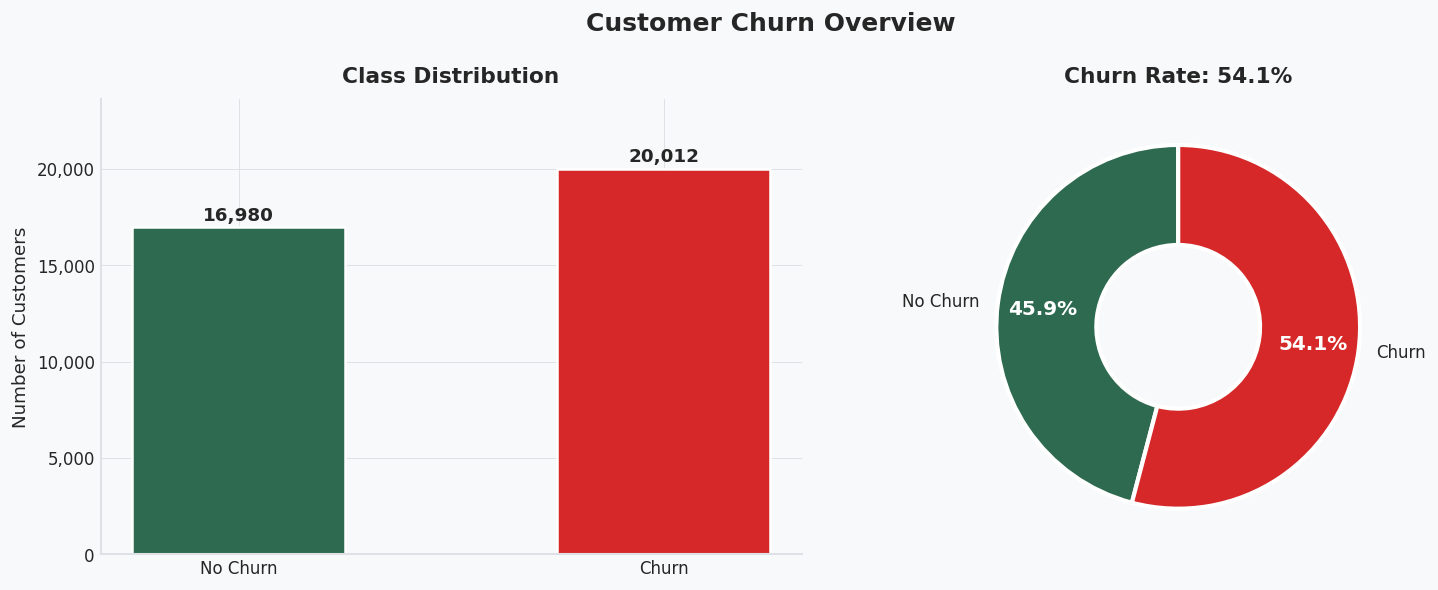

No Churn: 16,980  |  Churn: 20,012  |  Ratio: 0.85:1


In [12]:
# ── Chart 1: Target distribution ────────────────────────────────────────────────
counts     = df_clean[target].value_counts().sort_index()
labels     = ['No Churn', 'Churn']
churn_rate = df_clean[target].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Customer Churn Overview', fontsize=15, fontweight='bold')

bars = axes[0].bar(labels, counts.values, color=COLORS, width=0.5,
                   edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 150,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].set_ylim(0, counts.max() * 1.18)
style_ax(axes[0], 'Class Distribution', '', 'Number of Customers')

wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels, colors=COLORS,
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2.5}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')
axes[1].set_title(f'Churn Rate: {churn_rate:.1%}', pad=10, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print(f"No Churn: {counts[0]:,}  |  Churn: {counts[1]:,}  |  Ratio: {counts[0]/counts[1]:.2f}:1")

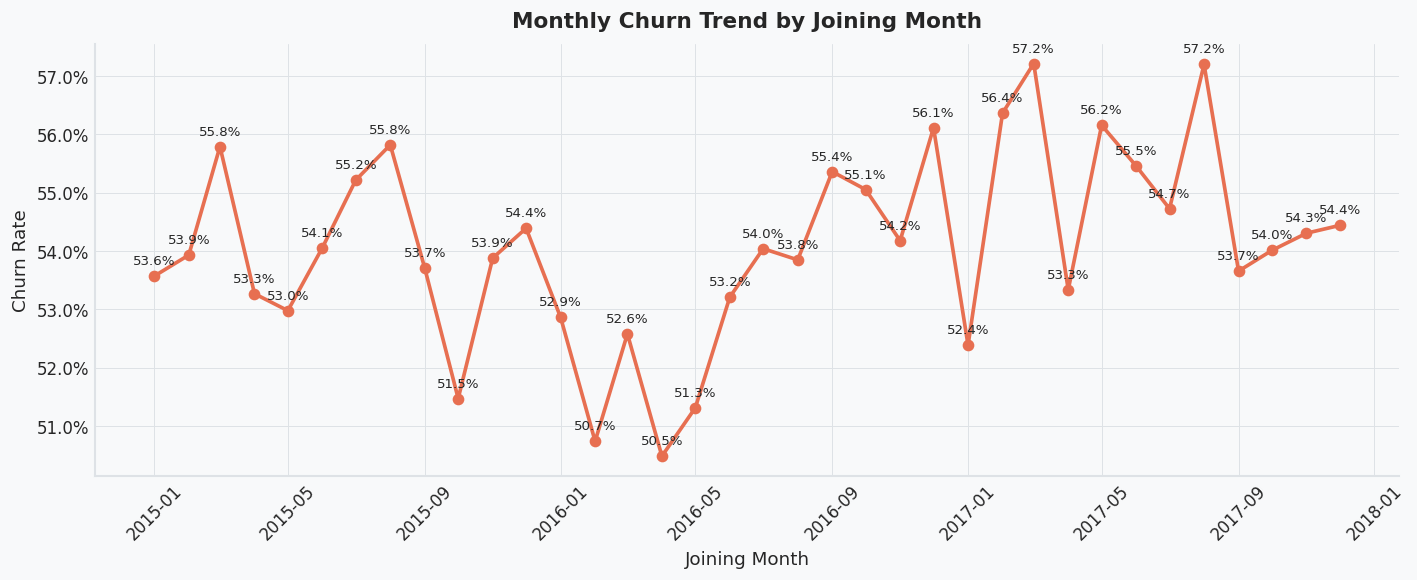


Interpretation: This chart shows how churn label prevalence varies across customer joining months. It is useful for checking broad temporal patterns or cohort shifts, but it should not be interpreted as the exact timing of churn events.


In [13]:
# ───────────────────────────────────────────────────────────────────────────────
# Temporal Trend Analysis
# ───────────────────────────────────────────────────────────────────────────────

def plot_monthly_churn_trend(data: pd.DataFrame,
                             date_col: str = 'joining_date',
                             target_col: str = 'churn_risk_score') -> pd.DataFrame:
    """
    Plot monthly churn trend based on joining_date.
    Note: This reflects acquisition-period churn distribution, not churn event timing.
    """
    trend_df = data.copy()
    trend_df['join_year_month'] = trend_df[date_col].dt.to_period('M').dt.to_timestamp()

    monthly = (
        trend_df.groupby('join_year_month')
        .agg(
            churn_rate=(target_col, 'mean'),
            customer_count=(target_col, 'size')
        )
        .reset_index()
        .sort_values('join_year_month')
    )

    fig, ax1 = plt.subplots(figsize=(12, 5))

    ax1.plot(
        monthly['join_year_month'],
        monthly['churn_rate'],
        marker='o',
        linewidth=2.2,
        color=ACCENTS[4],
        markersize=6
    )
    ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    style_ax(ax1, 'Monthly Churn Trend by Joining Month', 'Joining Month', 'Churn Rate')

    for x, y in zip(monthly['join_year_month'], monthly['churn_rate']):
        ax1.annotate(f'{y:.1%}', (x, y), textcoords='offset points', xytext=(0, 7),
                     ha='center', fontsize=8)

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return monthly

monthly_trend_df = plot_monthly_churn_trend(df_clean)

print(
    "\nInterpretation: This chart shows how churn label prevalence varies across customer "
    "joining months. It is useful for checking broad temporal patterns or cohort shifts, "
    "but it should not be interpreted as the exact timing of churn events."
)

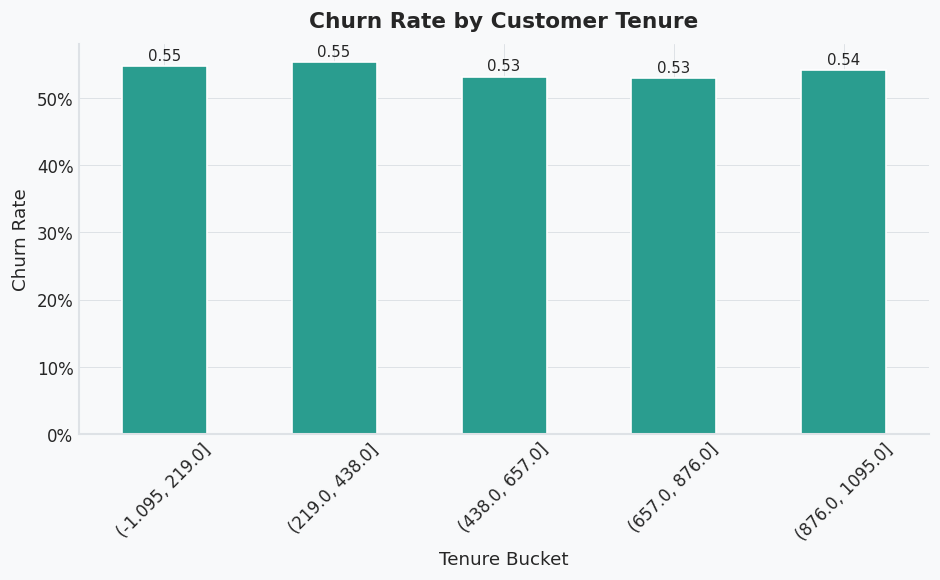

In [14]:
# ── Tenure Analysis ────────────────────────────────────────────────────────────
tenure_churn = df_clean.groupby('tenure_bin')[target].mean()

fig, ax = plt.subplots(figsize=(8, 5))
tenure_churn.plot(kind='bar', ax=ax, color=ACCENTS[1], edgecolor='white')
for bar, val in zip(ax.patches, tenure_churn):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
style_ax(ax, 'Churn Rate by Customer Tenure', 'Tenure Bucket', 'Churn Rate')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

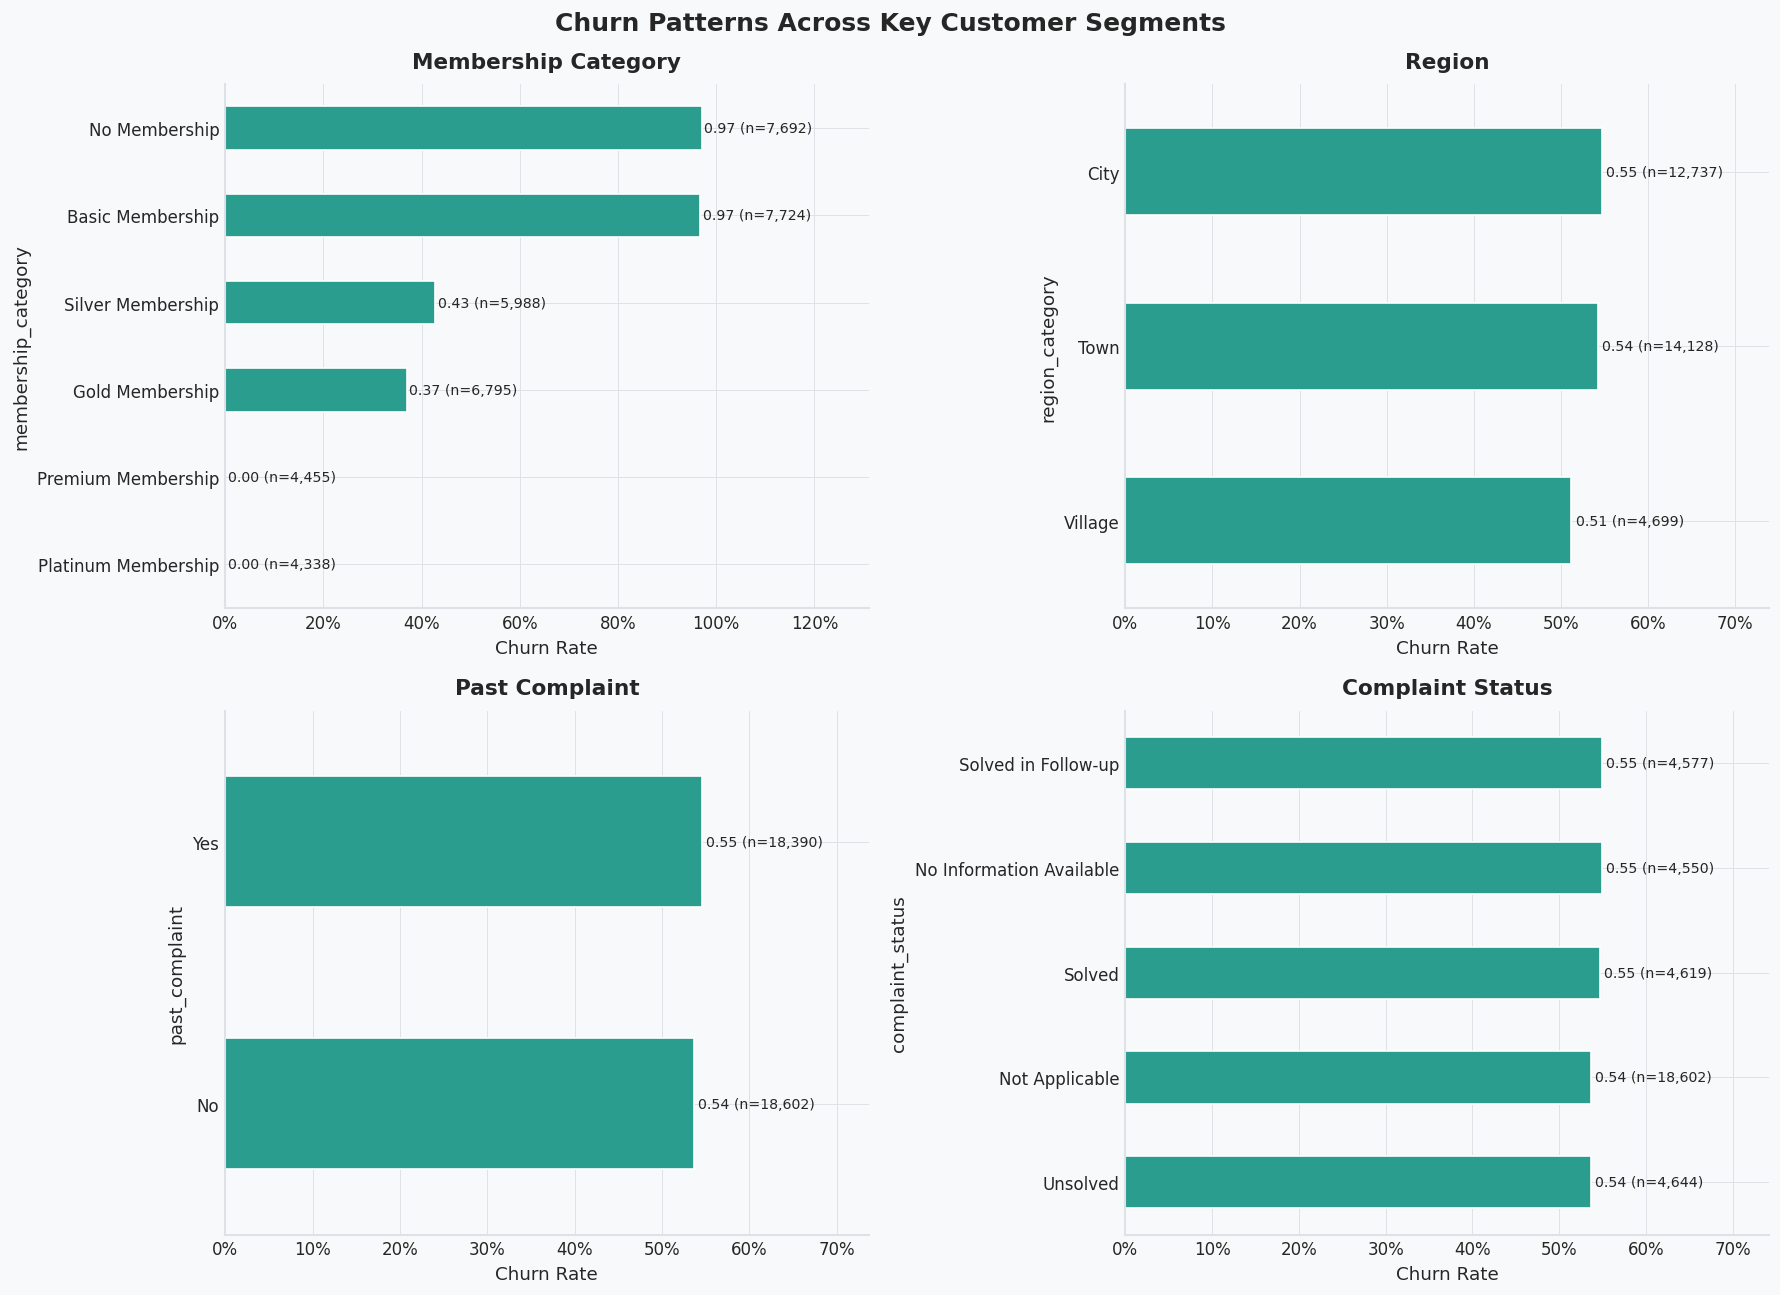

In [15]:
# ── Chart 2: Churn rate by key categorical features (sorted, annotated) ────────
cat_features = [
    ('membership_category', 'Membership Category'),
    ('region_category',     'Region'),
    ('past_complaint',      'Past Complaint'),
    ('complaint_status',    'Complaint Status'),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Churn Patterns Across Key Customer Segments', fontsize=15, fontweight='bold')

for ax, (col, title) in zip(axes.flat, cat_features):
    churn_rate_by_cat = (
        df_clean.groupby(col)[target].mean().sort_values()
    )
    counts_by_cat = df_clean[col].value_counts()
    bars = churn_rate_by_cat.plot(kind='barh', ax=ax, color=ACCENTS[1], edgecolor='white')
    for i, (cat, val) in enumerate(churn_rate_by_cat.items()):
        n = counts_by_cat.get(cat, 0)
        ax.text(val + 0.005, i, f'{val:.2f} (n={n:,})', va='center', fontsize=8.5)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.set_xlim(0, churn_rate_by_cat.max() * 1.35)
    style_ax(ax, title, 'Churn Rate', '')

plt.tight_layout()
plt.show()

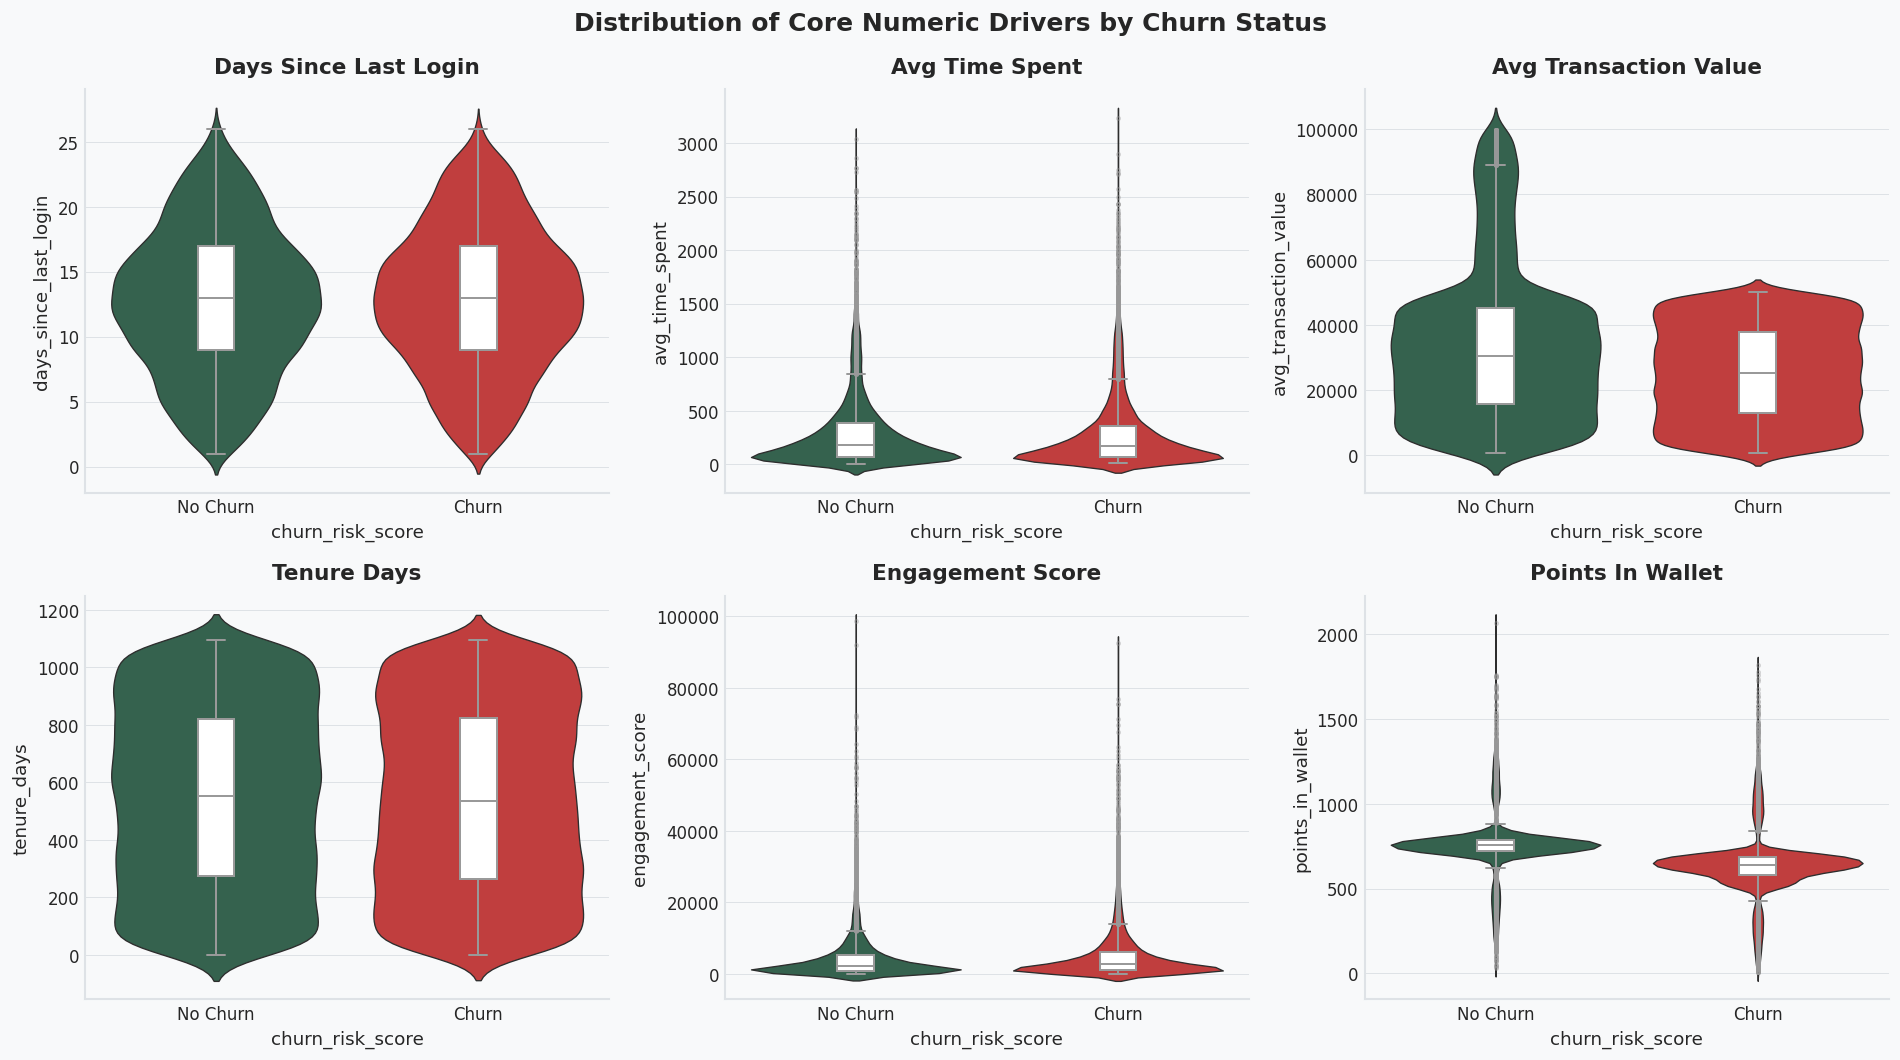

In [16]:
# ── Chart 3: Numerical features — violin + box overlay ─────────────────────────
engineered_numerical = [
    'days_since_last_login', 'avg_time_spent', 'avg_transaction_value',
    'tenure_days', 'engagement_score', 'points_in_wallet'
]
plot_df = df_clean[engineered_numerical + [target]].copy()
plot_df[target] = plot_df[target].map({0: 'No Churn', 1: 'Churn'})

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribution of Core Numeric Drivers by Churn Status', fontsize=15, fontweight='bold')

for ax, col in zip(axes.flat, engineered_numerical):
    sns.violinplot(data=plot_df, x=target, y=col, palette=COLORS,
                   order=['No Churn', 'Churn'], inner=None, linewidth=0.8, ax=ax)
    sns.boxplot(data=plot_df, x=target, y=col, order=['No Churn', 'Churn'],
                width=0.14, color='white', linewidth=1.2,
                flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.4}, ax=ax)
    style_ax(ax, col.replace('_', ' ').title(), '', '')

plt.tight_layout()
plt.show()

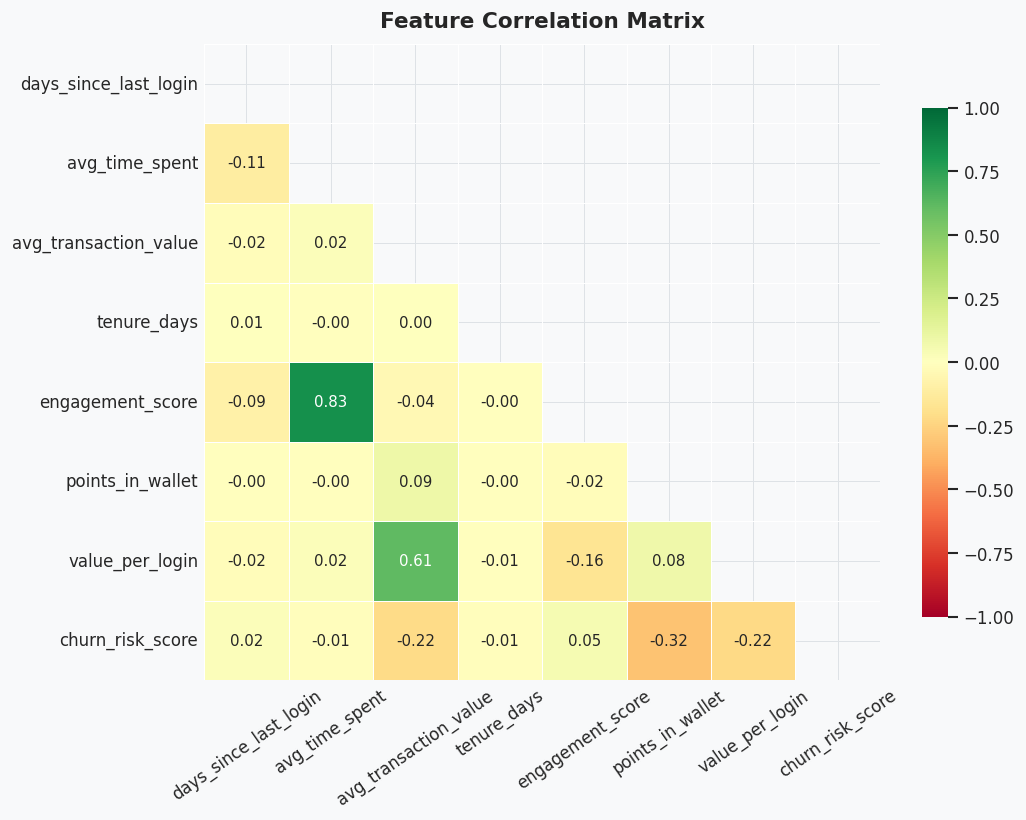


Correlation with churn:
engagement_score         0.046931
days_since_last_login    0.016773
tenure_days             -0.009913
avg_time_spent          -0.012146
avg_transaction_value   -0.218012
value_per_login         -0.220736
points_in_wallet        -0.315257
Name: churn_risk_score, dtype: float64


In [17]:
# ── Chart 4: Correlation heatmap ──────────────────────────────────────────────────
corr_cols   = engineered_numerical + ['value_per_login', target]
corr_matrix = df_clean[corr_cols].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}, ax=ax, cbar_kws={'shrink': 0.8}
)
style_ax(ax, 'Feature Correlation Matrix')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

correlations = corr_matrix[target].drop(target).sort_values(ascending=False)
print("\nCorrelation with churn:")
print(correlations)

## 7. Prepare Data for Modeling

In [18]:
# Drop identifiers, raw date/time columns, and analysis-only columns
drop_columns = id_columns + date_columns + ['joining_month', 'tenure_bin']

df_model = df_clean.drop(columns=drop_columns)

# last_visit_hour is treated as numerical (ordinal hour 0-23)
numerical_features_model = numerical_columns + [
    'tenure_days', 'engagement_score', 'value_per_login', 'last_visit_hour'
]
# Binary complaint features — no encoding needed
passthrough_features = ['had_complaint', 'complaint_unresolved']

X = df_model.drop(columns=[target])
y = df_model[target]

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Features: 24
Samples: 36992

Target distribution:
churn_risk_score
1    20012
0    16980
Name: count, dtype: int64


## 8. Train-Test Split

The test set is held out entirely and used only for final evaluation of the selected model.
All model comparison and selection is done via cross-validation on the training set.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTrain churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

Training set: 29593 samples
Test set: 7399 samples

Train churn rate: 54.10%
Test churn rate: 54.10%


## 9. Preprocessing Pipelines

Transformations are fit on training data only to prevent leakage.
- Logistic Regression uses a full Pipeline with OneHotEncoder + StandardScaler
- Tree-based models use a simpler ColumnTransformer (no scaling needed)

In [20]:
# Identify nominal categorical columns present in X
nominal_cats = [c for c in categorical_columns if c in X.columns]

# Imputer + scaler pipeline for numerical features (Logistic Regression)
num_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Imputer-only pipeline for numerical features (tree-based models)
num_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Imputer + encoder pipeline for categorical features
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Preprocessor for Logistic Regression: impute + scale numericals, impute + OHE categoricals
lr_preprocessor = ColumnTransformer(transformers=[
    ('num', num_lr, numerical_features_model),
    ('cat', cat_pipe, nominal_cats),
    ('pass', 'passthrough', passthrough_features)
])

# Preprocessor for tree-based models: impute numericals, impute + OHE categoricals, no scaling
tree_preprocessor = ColumnTransformer(transformers=[
    ('num', num_tree, numerical_features_model),
    ('cat', cat_pipe, nominal_cats),
    ('pass', 'passthrough', passthrough_features)
])

# Full pipelines
lr_pipeline = Pipeline([
    ('preprocessor', lr_preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

rf_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100, max_depth=10, min_samples_split=20,
        random_state=42, class_weight='balanced', n_jobs=-1
    ))
])

gb_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
    ))
])

### XGBoost Benchmark

XGBoost is included as an additional benchmark because this is a structured tabular dataset,
and gradient-boosted tree ensembles often perform strongly on this type of problem.
It is used here to test whether a more flexible boosting model improves predictive performance
beyond Random Forest and standard Gradient Boosting, while remaining interpretable enough
for a business-facing churn use case.

In [21]:
xgb_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        n_jobs=-1
    ))
])

print("Pipelines defined")

Pipelines defined


In [22]:
# Baseline model — majority class predictor
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)
print(f"Baseline (majority class) F1: {f1_score(y_test, y_dummy):.4f}")
print("(All models must beat this baseline to demonstrate value)")

Baseline (majority class) F1: 0.7022
(All models must beat this baseline to demonstrate value)


## 10. Cross-Validation on Training Set

Model selection is based on stratified cross-validation on the training set only.
The test set is not touched at this stage.

In [23]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

candidates = {
    'Logistic Regression': lr_pipeline,
    'Random Forest': rf_pipeline,
    'Gradient Boosting': gb_pipeline,
    'XGBoost': xgb_pipeline,
}

cv_results = {}
print("Running 5-fold stratified cross-validation on training set (scoring: F1)...\n")

for name, pipeline in candidates.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}: mean F1 = {scores.mean():.4f}  (+/- {scores.std():.4f})")

Running 5-fold stratified cross-validation on training set (scoring: F1)...

Logistic Regression: mean F1 = 0.8699  (+/- 0.0021)
Random Forest: mean F1 = 0.9341  (+/- 0.0019)
Gradient Boosting: mean F1 = 0.9408  (+/- 0.0024)
XGBoost: mean F1 = 0.9399  (+/- 0.0020)



Cross-validation summary:


,cv_f1_mean,cv_f1_std
Logistic Regression,0.869862,0.002117
Random Forest,0.934108,0.001900
Gradient Boosting,0.940778,0.002435
XGBoost,0.939905,0.001966


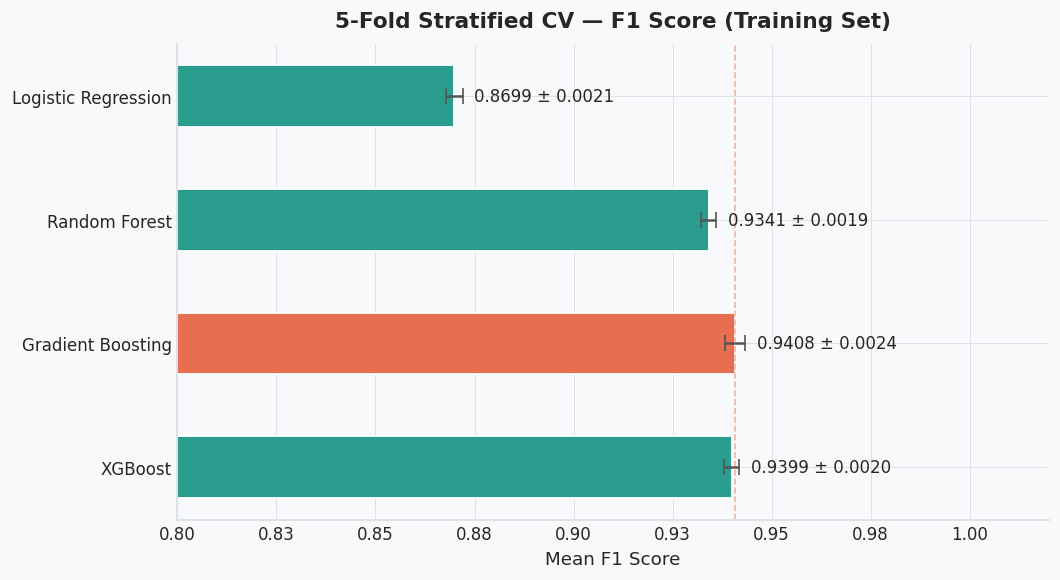

In [24]:
cv_summary = pd.DataFrame({
    name: {'cv_f1_mean': scores.mean(), 'cv_f1_std': scores.std()}
    for name, scores in cv_results.items()
}).T

print("\nCross-validation summary:")
display(cv_summary)

# ── Chart 5: CV comparison ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
means = cv_summary['cv_f1_mean']
stds  = cv_summary['cv_f1_std']
best  = means.idxmax()
bar_colors = [ACCENTS[4] if n == best else ACCENTS[1] for n in means.index]
bars = ax.barh(means.index, means, xerr=stds, color=bar_colors, capsize=5,
               edgecolor='white', linewidth=1.1, height=0.5,
               error_kw={'elinewidth': 1.5, 'ecolor': '#555'})
for bar, val, std in zip(bars, means, stds):
    ax.text(val + std + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f} ± {std:.4f}', va='center', fontsize=10)
ax.set_xlim(0.80, 1.02)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}'))
ax.axvline(means.max(), color=ACCENTS[4], linestyle='--', linewidth=1, alpha=0.5)
ax.invert_yaxis()
style_ax(ax, '5-Fold Stratified CV — F1 Score (Training Set)', 'Mean F1 Score', '')
plt.tight_layout()
plt.show()

## 11. Model Selection

The model with the highest mean CV F1 on the training set is selected.
The test set is used only once, for final evaluation of the chosen model.

In [25]:
best_model_name = cv_summary['cv_f1_mean'].idxmax()
best_pipeline = candidates[best_model_name]

print(f"Selected model: {best_model_name}")
print(f"CV F1 mean: {cv_summary.loc[best_model_name, 'cv_f1_mean']:.4f}")
print("Rationale: highest mean F1 across 5 stratified folds on training data")
print("\nFitting selected model on full training set...")

best_pipeline.fit(X_train, y_train)
print("Done.")

Selected model: Gradient Boosting
CV F1 mean: 0.9408
Rationale: highest mean F1 across 5 stratified folds on training data

Fitting selected model on full training set...
Done.


## 12. Final Evaluation on Held-Out Test Set

This section is run once, after model selection is complete.

In [26]:
def evaluate_model(pipeline, X_tr, X_te, y_tr, y_te, model_name):
    """Evaluate a fitted pipeline on train and test sets."""
    y_train_pred = pipeline.predict(X_tr)
    y_test_pred = pipeline.predict(X_te)
    y_test_proba = pipeline.predict_proba(X_te)[:, 1]

    print(f"\n{'='*60}")
    print(f"{model_name} — Final Evaluation")
    print(f"{'='*60}")

    print("\nTrain Metrics:")
    print(f"  F1:        {f1_score(y_tr, y_train_pred):.4f}")
    print(f"  Precision: {precision_score(y_tr, y_train_pred):.4f}")
    print(f"  Recall:    {recall_score(y_tr, y_train_pred):.4f}")

    print("\nTest Metrics:")
    print(f"  F1:        {f1_score(y_te, y_test_pred):.4f}")
    print(f"  Precision: {precision_score(y_te, y_test_pred):.4f}")
    print(f"  Recall:    {recall_score(y_te, y_test_pred):.4f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_te, y_test_proba):.4f}")

    print("\nClassification Report (Test):")
    print(classification_report(y_te, y_test_pred, target_names=['No Churn', 'Churn']))

    # ── Chart 6: Confusion matrix + ROC curve ─────────────────────────────────────
    cm = confusion_matrix(y_te, y_test_pred)
    fpr, tpr, _ = roc_curve(y_te, y_test_proba)
    auc_val = roc_auc_score(y_te, y_test_proba)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'{model_name} — Final Evaluation (Test Set)',
                 fontsize=14, fontweight='bold')

    # Confusion matrix with counts + row percentages
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot  = np.array([[f'{v:,}\n({p:.1f}%)' for v, p in zip(rv, rp)]
                        for rv, rp in zip(cm, cm_pct)])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', linewidths=1,
                linecolor='white', annot_kws={'size': 11},
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                ax=axes[0], cbar_kws={'shrink': 0.8})
    style_ax(axes[0], 'Confusion Matrix', 'Predicted', 'Actual')

    # ROC curve with AUC fill
    axes[1].plot(fpr, tpr, color=ACCENTS[4], lw=2.5, label=f'AUC = {auc_val:.4f}')
    axes[1].fill_between(fpr, tpr, alpha=0.08, color=ACCENTS[4])
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4, label='Random')
    axes[1].set_xlim([-0.01, 1.01])
    axes[1].set_ylim([-0.01, 1.05])
    axes[1].legend(loc='lower right', frameon=True)
    style_ax(axes[1], 'ROC Curve', 'False Positive Rate', 'True Positive Rate')

    plt.tight_layout()
    plt.show()

    return {
        'f1': f1_score(y_te, y_test_pred),
        'precision': precision_score(y_te, y_test_pred),
        'recall': recall_score(y_te, y_test_pred),
        'roc_auc': roc_auc_score(y_te, y_test_proba)
    }


Gradient Boosting — Final Evaluation

Train Metrics:
  F1:        0.9519
  Precision: 0.9510
  Recall:    0.9528

Test Metrics:
  F1:        0.9391
  Precision: 0.9364
  Recall:    0.9418
  ROC-AUC:   0.9759

Classification Report (Test):
              precision    recall  f1-score   support

    No Churn       0.93      0.92      0.93      3396
       Churn       0.94      0.94      0.94      4003

    accuracy                           0.93      7399
   macro avg       0.93      0.93      0.93      7399
weighted avg       0.93      0.93      0.93      7399



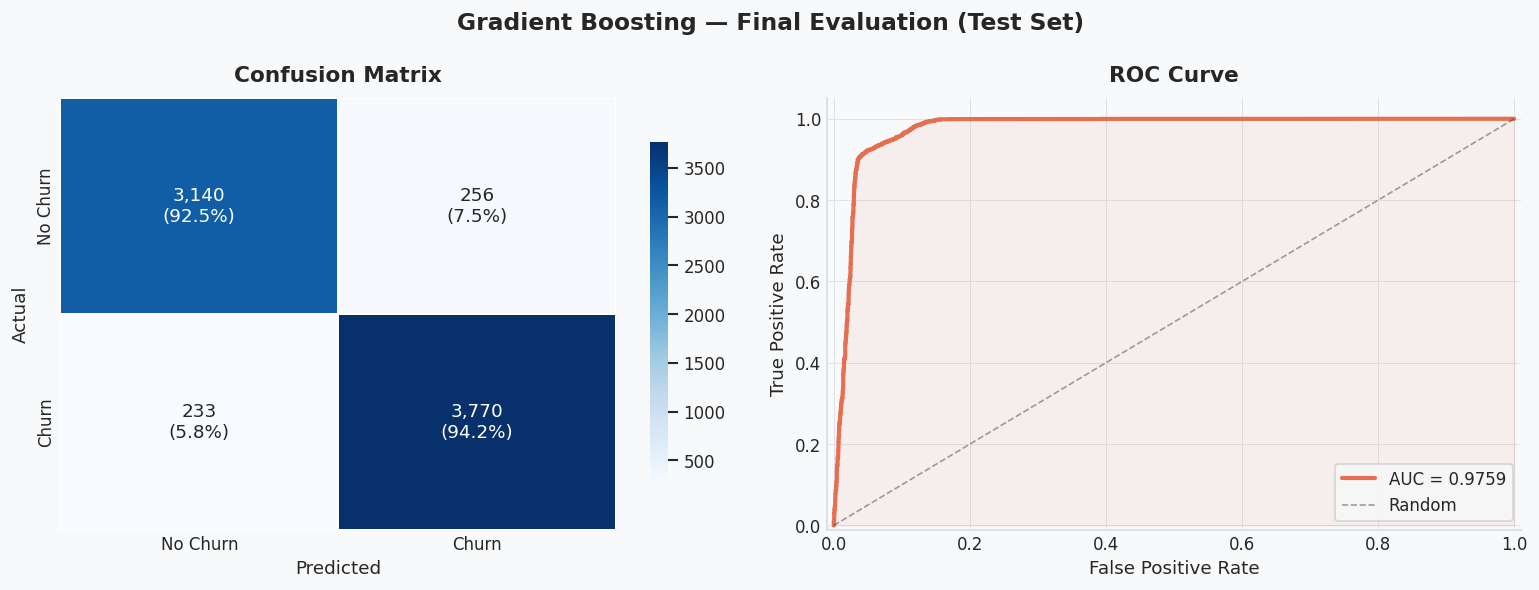

In [27]:
final_metrics = evaluate_model(best_pipeline, X_train, X_test, y_train, y_test, best_model_name)

In [28]:
# ── Threshold tuning ──────────────────────────────────────────────────────────
# Default threshold (0.5) optimises accuracy; adjust for business intervention capacity.
y_probs = best_pipeline.predict_proba(X_test)[:, 1]

print("Threshold sensitivity:")
for threshold in [0.4, 0.5, 0.6]:
    y_custom = (y_probs > threshold).astype(int)
    print(f"  threshold={threshold:.1f}  F1={f1_score(y_test, y_custom):.4f}  "
          f"Precision={precision_score(y_test, y_custom):.4f}  "
          f"Recall={recall_score(y_test, y_custom):.4f}")
print("\nNote: threshold is tuned for business intervention capacity.")

Threshold sensitivity:
  threshold=0.4  F1=0.9419  Precision=0.9025  Recall=0.9850
  threshold=0.5  F1=0.9391  Precision=0.9364  Recall=0.9418
  threshold=0.6  F1=0.9388  Precision=0.9565  Recall=0.9218

Note: threshold is tuned for business intervention capacity.


## 13. Model Explainability

In [29]:
# Feature names after preprocessing
try:
    ohe_feature_names = (
        best_pipeline.named_steps['preprocessor']
        .named_transformers_['cat']
        .named_steps['encoder']
        .get_feature_names_out(nominal_cats)
        .tolist()
    )
    all_feature_names = numerical_features_model + ohe_feature_names + passthrough_features
except Exception:
    all_feature_names = list(X.columns)


Top 15 Feature Importances (Gradient Boosting):
                                feature  importance
                       points_in_wallet    0.572369
      membership_category_No Membership    0.131480
   membership_category_Basic Membership    0.115304
membership_category_Platinum Membership    0.064583
 membership_category_Premium Membership    0.063457
                  avg_transaction_value    0.017169
    membership_category_Gold Membership    0.011265
  membership_category_Silver Membership    0.004907
              feedback_Reasonable Price    0.002779
      feedback_Products always in Stock    0.002336
         feedback_Quality Customer Care    0.002272
         feedback_User Friendly Website    0.002145
                         avg_time_spent    0.001571
                        value_per_login    0.001364
                            tenure_days    0.001245


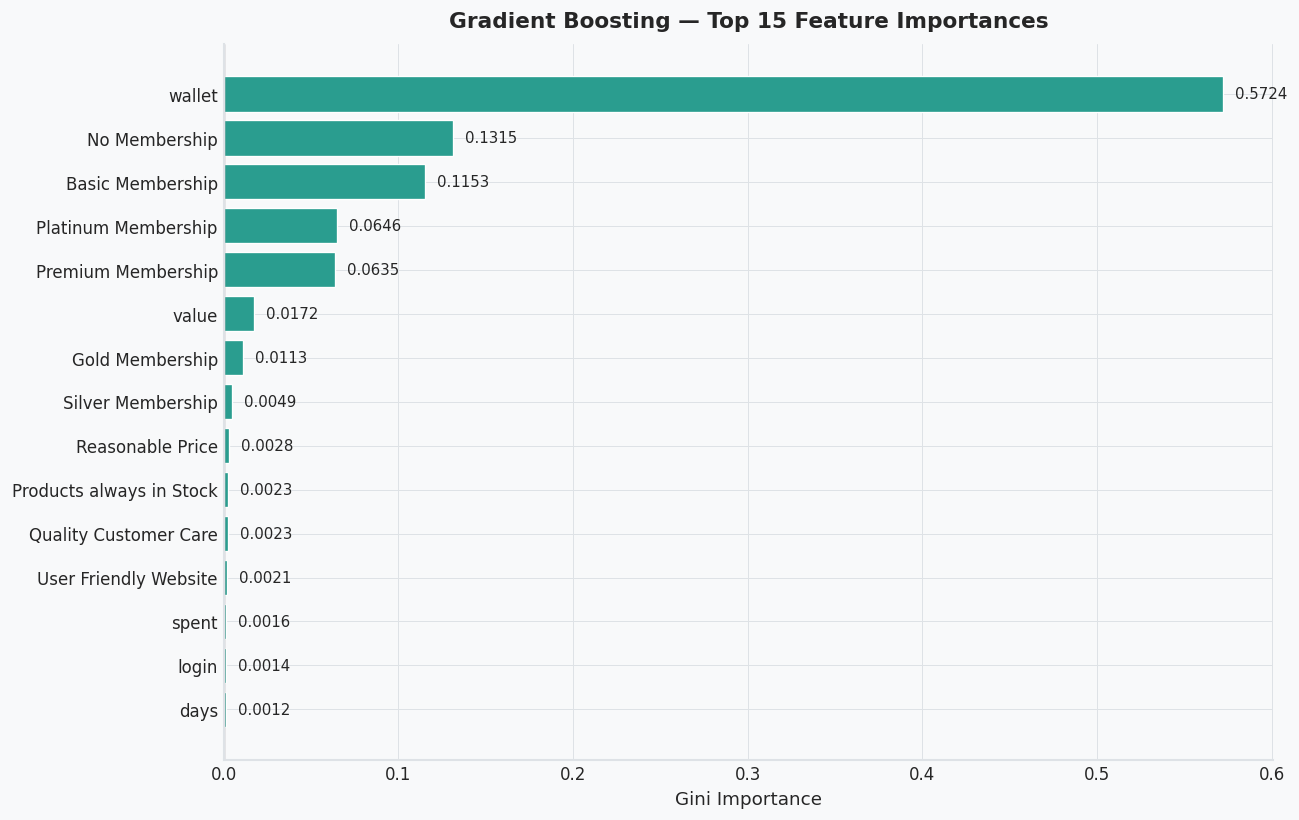

In [30]:
inner_model = best_pipeline.named_steps['model']

def _importance_chart(df_imp, value_col, title, xlabel, color):
    """Reusable professional horizontal importance bar chart."""
    top = df_imp.head(15).copy()
    top['label'] = top['feature'].str.replace(r'^[a-z_]+_', '', regex=True)
    bar_colors = [color if v >= 0 else PALETTE['churn'] for v in top[value_col]]
    fig, ax = plt.subplots(figsize=(11, 7))
    bars = ax.barh(top['label'], top[value_col], color=bar_colors,
                   edgecolor='white', linewidth=0.8)
    max_val = top[value_col].abs().max()
    for bar, val in zip(bars, top[value_col]):
        ax.text(val + max_val * 0.012, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.invert_yaxis()
    ax.axvline(0, color='#888', linewidth=0.8)
    style_ax(ax, title, xlabel, '')
    plt.tight_layout()
    plt.show()

if hasattr(inner_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': all_feature_names,
        'importance': inner_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"\nTop 15 Feature Importances ({best_model_name}):")
    print(feature_importance.head(15).to_string(index=False))
    _importance_chart(feature_importance, 'importance',
                      f'{best_model_name} — Top 15 Feature Importances',
                      'Gini Importance', ACCENTS[1])

elif hasattr(inner_model, 'coef_'):
    feature_importance = pd.DataFrame({
        'feature': all_feature_names,
        'coefficient': inner_model.coef_[0]
    }).sort_values('coefficient', key=abs, ascending=False)

    print(f"\nTop 15 Feature Coefficients ({best_model_name}):")
    print(feature_importance.head(15).to_string(index=False))
    _importance_chart(feature_importance, 'coefficient',
                      f'{best_model_name} — Top 15 Feature Coefficients',
                      'Coefficient', ACCENTS[1])


Calculating permutation importance on test set...

Top 15 Permutation Importances:
                                feature  importance
      membership_category_No Membership    0.095432
   membership_category_Basic Membership    0.093013
                       points_in_wallet    0.089877
membership_category_Platinum Membership    0.057738
 membership_category_Premium Membership    0.056575
                  avg_transaction_value    0.019732
      feedback_Products always in Stock    0.014961
         feedback_Quality Customer Care    0.013191
         feedback_User Friendly Website    0.013002
              feedback_Reasonable Price    0.004217
    membership_category_Gold Membership    0.001649
               avg_frequency_login_days    0.000514
                       engagement_score    0.000419
                        last_visit_hour    0.000270
                   complaint_unresolved    0.000243


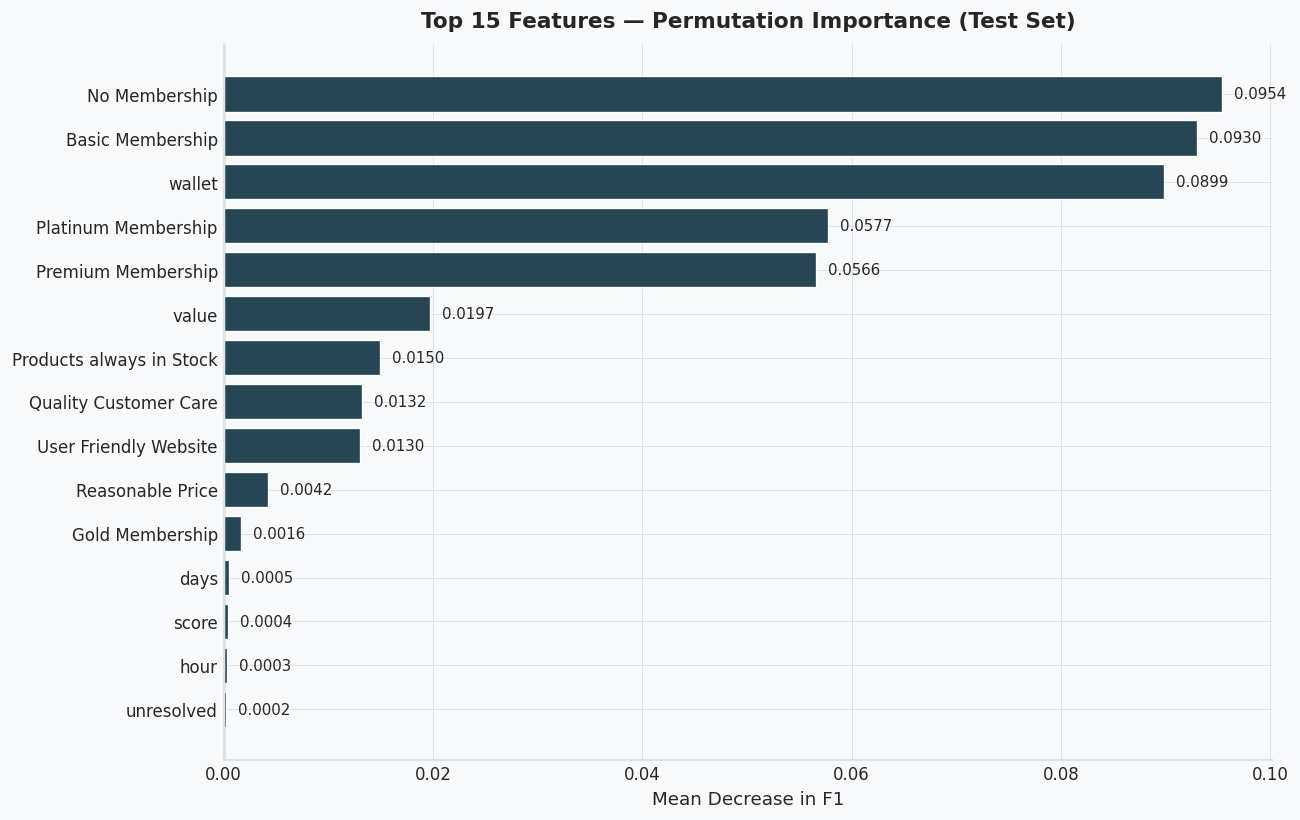

In [31]:
# Permutation importance on the test set (model-agnostic, uses the full pipeline)
print("\nCalculating permutation importance on test set...")
X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X_test)

perm_imp = permutation_importance(
    inner_model, X_test_transformed, y_test,
    n_repeats=10, random_state=42, n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': perm_imp.importances_mean
}).sort_values('importance', ascending=False)

print("\nTop 15 Permutation Importances:")
print(perm_importance_df.head(15).to_string(index=False))
_importance_chart(perm_importance_df, 'importance',
                  'Top 15 Features — Permutation Importance (Test Set)',
                  'Mean Decrease in F1', ACCENTS[0])

## 14. Business Insights and Recommendations

In [32]:
print("\n" + "="*80)
print("BUSINESS INSIGHTS AND RECOMMENDATIONS")
print("="*80)

print("\n1. KEY CHURN DRIVERS:")
print("-" * 80)
top_features = perm_importance_df.head(10)['feature'].tolist()
print("Based on permutation importance, the strongest churn predictors are:")
for i, feature in enumerate(top_features[:5], 1):
    print(f"   {i}. {feature}")

print("\n2. HIGH-RISK CUSTOMER SEGMENTS:")
print("-" * 80)
print("   • Customers in higher-risk membership categories")
print("   • Customers with lower points_in_wallet balances")
print("   • Customers with lower transaction value signals")
print("   • Customers showing disengagement patterns (low activity, infrequent logins)")
print("   • Complaint-related signals may provide additional prioritisation support")

print("\n3. ACTIONABLE RECOMMENDATIONS:")
print("-" * 80)
print("   A. Complaint Resolution Priority")
print("      → Immediately address all open/unresolved complaints")
print("      → Implement proactive outreach for customers with past complaints")
print("      → Track complaint resolution time as a KPI")

print("\n   B. Re-engagement Campaigns")
print("      → Target customers with >30 days since last login")
print("      → Personalised offers based on preferred_offer_types")
print("      → Win-back campaigns for low engagement customers")

print("\n   C. Membership Optimisation")
print("      → Review pricing and benefits for high-churn membership tiers")
print("      → Offer upgrade incentives to retain valuable customers")
print("      → Create loyalty programs for long-tenure customers")

print("\n   D. Proactive Retention")
print("      → Score all customers monthly using this model")
print("      → Trigger interventions for customers with churn probability > 0.6")
print("      → A/B test retention offers on medium-risk customers (0.4–0.6)")

print("\n4. EXPECTED BUSINESS IMPACT:")
print("-" * 80)
print(f"   • Model recall:    {final_metrics['recall']:.1%} of churners identified")
print(f"   • Model precision: {final_metrics['precision']:.1%} of flagged customers are true churners")
print("   • If 20% of identified churners are saved through intervention:")
print(f"     → Potential churn reduction: ~{final_metrics['recall'] * 0.20:.1%} of total churn")


BUSINESS INSIGHTS AND RECOMMENDATIONS

1. KEY CHURN DRIVERS:
--------------------------------------------------------------------------------
Based on permutation importance, the strongest churn predictors are:
   1. membership_category_No Membership
   2. membership_category_Basic Membership
   3. points_in_wallet
   4. membership_category_Platinum Membership
   5. membership_category_Premium Membership

2. HIGH-RISK CUSTOMER SEGMENTS:
--------------------------------------------------------------------------------
   • Customers in higher-risk membership categories
   • Customers with lower points_in_wallet balances
   • Customers with lower transaction value signals
   • Customers showing disengagement patterns (low activity, infrequent logins)
   • Complaint-related signals may provide additional prioritisation support

3. ACTIONABLE RECOMMENDATIONS:
--------------------------------------------------------------------------------
   A. Complaint Resolution Priority
      → Immedia

## 15. Next Steps and Production Considerations

In [33]:
print("\n" + "="*80)
print("NEXT STEPS FOR PRODUCTION DEPLOYMENT")
print("="*80)

print("\n1. MODEL VALIDATION:")
print("-" * 80)
print("   • Conduct A/B test: control group (no intervention) vs treatment group")
print("   • Validate model performance on out-of-time data (next 3 months)")
print("   • Calculate ROI: cost of interventions vs value of retained customers")

print("\n2. PRODUCTION PIPELINE:")
print("-" * 80)
print("   • Automate data pipeline to refresh customer features daily/weekly")
print("   • Deploy model as REST API or batch scoring service")
print("   • Integrate churn scores into CRM system for operations team")
print("   • Create dashboard for monitoring high-risk customers")

print("\n3. DATA QUALITY AND MONITORING:")
print("-" * 80)
print("   • Monitor feature distributions for data drift")
print("   • Set up alerts for missing data or anomalous values")
print("   • Track model performance metrics over time")
print("   • Implement feedback loop: track actual churn vs predictions")

print("\n4. MODEL MAINTENANCE:")
print("-" * 80)
print("   • Retrain model quarterly with new data")
print("   • Monitor for concept drift (changing churn patterns)")
print("   • Version control for models and features")

print("\n5. OPERATIONAL INTEGRATION:")
print("-" * 80)
print("   • Train customer success team on using churn scores")
print("   • Define intervention playbooks for different risk levels:")
print("     → High risk (> 0.7):   immediate personal outreach")
print("     → Medium risk (0.4–0.7): targeted offers and campaigns")
print("     → Low risk (< 0.4):    standard engagement")

print("\n6. ETHICAL AND PRIVACY CONSIDERATIONS:")
print("-" * 80)
print("   • Ensure compliance with data privacy regulations")
print("   • Avoid discriminatory patterns in model predictions")
print("   • Regular bias audits across customer segments")

print("\n" + "="*80)
print("FINAL SUMMARY AND BUSINESS READOUT")
print("="*80)

metric_block("Model Performance Summary", {
    "Selected model": best_model_name,
    "CV F1 (mean)": cv_summary.loc[best_model_name, 'cv_f1_mean'],
    "Test F1": final_metrics['f1'],
    "Test Recall": final_metrics['recall'],
    "Test ROC-AUC": final_metrics['roc_auc']
})
print("\nThis model shows strong predictive signal, but requires validation on "
      "out-of-time data and refined data quality checks before production use.")


NEXT STEPS FOR PRODUCTION DEPLOYMENT

1. MODEL VALIDATION:
--------------------------------------------------------------------------------
   • Conduct A/B test: control group (no intervention) vs treatment group
   • Validate model performance on out-of-time data (next 3 months)
   • Calculate ROI: cost of interventions vs value of retained customers

2. PRODUCTION PIPELINE:
--------------------------------------------------------------------------------
   • Automate data pipeline to refresh customer features daily/weekly
   • Deploy model as REST API or batch scoring service
   • Integrate churn scores into CRM system for operations team
   • Create dashboard for monitoring high-risk customers

3. DATA QUALITY AND MONITORING:
--------------------------------------------------------------------------------
   • Monitor feature distributions for data drift
   • Set up alerts for missing data or anomalous values
   • Track model performance metrics over time
   • Implement feedback l

In [34]:
subsection_title("Limitations and Caveats")
print("- Data contains placeholder values ('?', 'xxxxxxx') treated as missing")
print("- Sentinel value -999 found in days_since_last_login; replaced with NaN")
print("- No explicit churn timestamp available; churn_risk_score indicates churn likelihood, not actual churn timing")
print("- Time-based (out-of-time) validation not possible with this static dataset")
print("- Some features may act as proxies rather than causal drivers")
print("- complaint_status values may vary in production; complaint features built defensively")
print("- All model features should be confirmed as available at scoring time in production workflows")


Limitations and Caveats
-----------------------
- Data contains placeholder values ('?', 'xxxxxxx') treated as missing
- Sentinel value -999 found in days_since_last_login; replaced with NaN
- No explicit churn timestamp available; churn_risk_score indicates churn likelihood, not actual churn timing
- Time-based (out-of-time) validation not possible with this static dataset
- Some features may act as proxies rather than causal drivers
- complaint_status values may vary in production; complaint features built defensively
- All model features should be confirmed as available at scoring time in production workflows
